<a href="https://colab.research.google.com/github/24Priyanshi/period-tracker/blob/main/mensturalTracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# 1. Load data
hormones = pd.read_csv('/content/drive/MyDrive/MensturalTracker/hormones_and_selfreport.csv')
active = pd.read_csv('/content/drive/MyDrive/MensturalTracker/active_minutes.csv')
stress = pd.read_csv('/content/drive/MyDrive/MensturalTracker/stress_score.csv')

# 2. Aggregate Stress (take the mean per day per user)
stress_daily = stress.groupby(['id', 'study_interval', 'day_in_study'])['stress_score'].mean().reset_index()

# 3. Encode the symptoms (Simplified mapping)
mapping = {'Not at all': 0, 'Very Low/Little': 1, 'Low': 1, 'Moderate': 2, 'High': 3, 'Very High': 4}
symptom_cols = ['cramps', 'fatigue', 'moodswing', 'stress', 'bloating']

for col in symptom_cols:
    if col in hormones.columns:
        hormones[col] = hormones[col].map(mapping).fillna(0)

# 4. Merge everything
# We use 'inner' or 'left' join based on hormones as it is our primary source
df_final = hormones.merge(active[['id', 'day_in_study', 'sedentary', 'lightly']], on=['id', 'day_in_study'], how='left')
df_final = df_final.merge(stress_daily, on=['id', 'day_in_study'], how='left')

# Drop columns we don't need for the LSTM right now
df_final = df_final.drop(columns=['flow_color', 'flow_volume', 'is_weekend_x', 'is_weekend_y'], errors='ignore')

print(f"Final dataset shape: {df_final.shape}")
df_final.head()

Final dataset shape: (5730, 24)


,id,study_interval_x,is_weekend,day_in_study,phase,lh,estrogen,pdg,appetite,exerciselevel,...,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,sedentary,lightly,study_interval_y,stress_score
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Low,Low,...,Low,1.0,2.0,Very Low/Little,Very Low/Little,1.0,753.0,64.0,NaN,NaN
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Low,Low,...,Very High,1.0,2.0,Very Low/Little,Very Low/Little,1.0,855.0,74.0,NaN,NaN
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Very Low,Very Low,...,Very High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,751.0,134.0,NaN,NaN
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Low,Low,...,Very High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,905.0,86.0,NaN,NaN
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Very Low,Very Low,...,High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,1430.0,10.0,NaN,NaN


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/MensturalTracker/processed_period_data.csv')

# Inspect the columns and data types
print(df.info())
print(df.head())
print("Unique phases:", df['phase'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5730 entries, 0 to 5729
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                5730 non-null   int64  
 1   study_interval_x  5730 non-null   int64  
 2   is_weekend        5730 non-null   bool   
 3   day_in_study      5730 non-null   int64  
 4   phase             5729 non-null   object 
 5   lh                5408 non-null   float64
 6   estrogen          5407 non-null   float64
 7   pdg               1933 non-null   float64
 8   appetite          3330 non-null   object 
 9   exerciselevel     3330 non-null   object 
 10  headaches         3328 non-null   object 
 11  cramps            5730 non-null   float64
 12  sorebreasts       3327 non-null   object 
 13  fatigue           5730 non-null   float64
 14  sleepissue        3329 non-null   object 
 15  moodswing         5730 non-null   float64
 16  stress            5730 non-null   float64


In [5]:
import numpy as np

# Map categorical symptom values to numerical
symptom_map = {
    'Very Low/Little': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

categorical_cols = ['appetite', 'exerciselevel', 'headaches', 'sorebreasts', 'sleepissue', 'foodcravings', 'indigestion']

for col in categorical_cols:
    df[col] = df[col].map(symptom_map)

# Fill NaNs in symptom columns with 0 (assuming missing means not present/very low)
df[categorical_cols] = df[categorical_cols].fillna(0)

# Also handle numerical missing values
# For hormone levels, interpolate per user or fill with median
df['lh'] = df.groupby('id')['lh'].transform(lambda x: x.interpolate().fillna(x.median()))
df['estrogen'] = df.groupby('id')['estrogen'].transform(lambda x: x.interpolate().fillna(x.median()))
df['pdg'] = df.groupby('id')['pdg'].transform(lambda x: x.interpolate().fillna(x.median()))

# Fill remaining NaNs (if any) with overall median
df = df.fillna(df.median(numeric_only=True))

# Identify period starts
# A period start is the first day of 'Menstrual' phase after a different phase
df['is_menstrual'] = (df['phase'] == 'Menstrual').astype(int)
df['prev_phase'] = df.groupby('id')['phase'].shift(1)
df['period_start'] = ((df['phase'] == 'Menstrual') & (df['prev_phase'] != 'Menstrual')).astype(int)

# Check how many period starts we have
print("Total records:", len(df))
print("Total period starts identified:", df['period_start'].sum())

# Let's see some samples of period start
print(df[df['period_start'] == 1][['id', 'day_in_study', 'phase', 'prev_phase']].head())

# Drop helper columns
# df.drop(columns=['prev_phase'], inplace=True)

Total records: 5730
Total period starts identified: 192
     id  day_in_study      phase prev_phase
21    1            22  Menstrual     Luteal
51    1            52  Menstrual     Luteal
77    1            78  Menstrual     Luteal
109   2            20  Menstrual     Luteal
140   2            51  Menstrual     Luteal


In [6]:
def calculate_days_until_next(group):
    # Get indices where period starts
    start_indices = group.index[group['period_start'] == 1].tolist()

    targets = []
    for idx in group.index:
        # Find the first start_index that is > current index
        # If we use >= idx, then on the first day of period, target is 0.
        future_starts = [s for s in start_indices if s > idx]
        if future_starts:
            targets.append(future_starts[0] - idx)
        else:
            targets.append(np.nan) # No future period start recorded for this user

    group['days_to_period'] = targets
    return group

df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)

# Remove rows where we don't have a future period start (can't train on them)
df_clean = df.dropna(subset=['days_to_period'])

print(f"Rows remaining after target calculation: {len(df_clean)}")
print(df_clean[['id', 'day_in_study', 'phase', 'period_start', 'days_to_period']].head(30))

Rows remaining after target calculation: 4889
    id  day_in_study       phase  period_start  days_to_period
0    1             1  Follicular             0            21.0
1    1             2  Follicular             0            20.0
2    1             3  Follicular             0            19.0
3    1             4   Fertility             0            18.0
4    1             5   Fertility             0            17.0
5    1             6   Fertility             0            16.0
6    1             7   Fertility             0            15.0
7    1             8   Fertility             0            14.0
8    1             9   Fertility             0            13.0
9    1            10      Luteal             0            12.0
10   1            11      Luteal             0            11.0
11   1            12      Luteal             0            10.0
12   1            13      Luteal             0             9.0
13   1            14      Luteal             0             8.0
14   1   

/tmp/ipykernel_2297/1918736157.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)


In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Features to use
features = ['lh', 'estrogen', 'pdg', 'appetite', 'exerciselevel', 'headaches',
            'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing',
            'stress', 'foodcravings', 'indigestion', 'bloating', 'sedentary',
            'lightly', 'is_weekend']

# Scale features
scaler = MinMaxScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

# Prepare sequences
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(target[i + lookback])
    return np.array(X), np.array(y)

# We should create sequences per user to avoid mixing different users' data at boundaries
X_list, y_list = [], []
lookback = 45
for user_id in df_clean['id'].unique():
    user_data = df_clean[df_clean['id'] == user_id]
    if len(user_data) > lookback:
        X_user, y_user = create_sequences(user_data[features].values,
                                          user_data['days_to_period'].values,
                                          lookback)
        X_list.append(X_user)
        y_list.append(y_user)

X = np.concatenate(X_list)
y = np.concatenate(y_list)

print(f"Total sequences: {len(X)}")
print(f"Shape of X: {X.shape}") # (Samples, Lookback, Features)
print(f"Shape of y: {y.shape}") # (Samples,)

Total sequences: 3013
Shape of X: (3013, 45, 18)
Shape of y: (3013,)


/tmp/ipykernel_2297/1952436610.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[features] = scaler.fit_transform(df_clean[features])


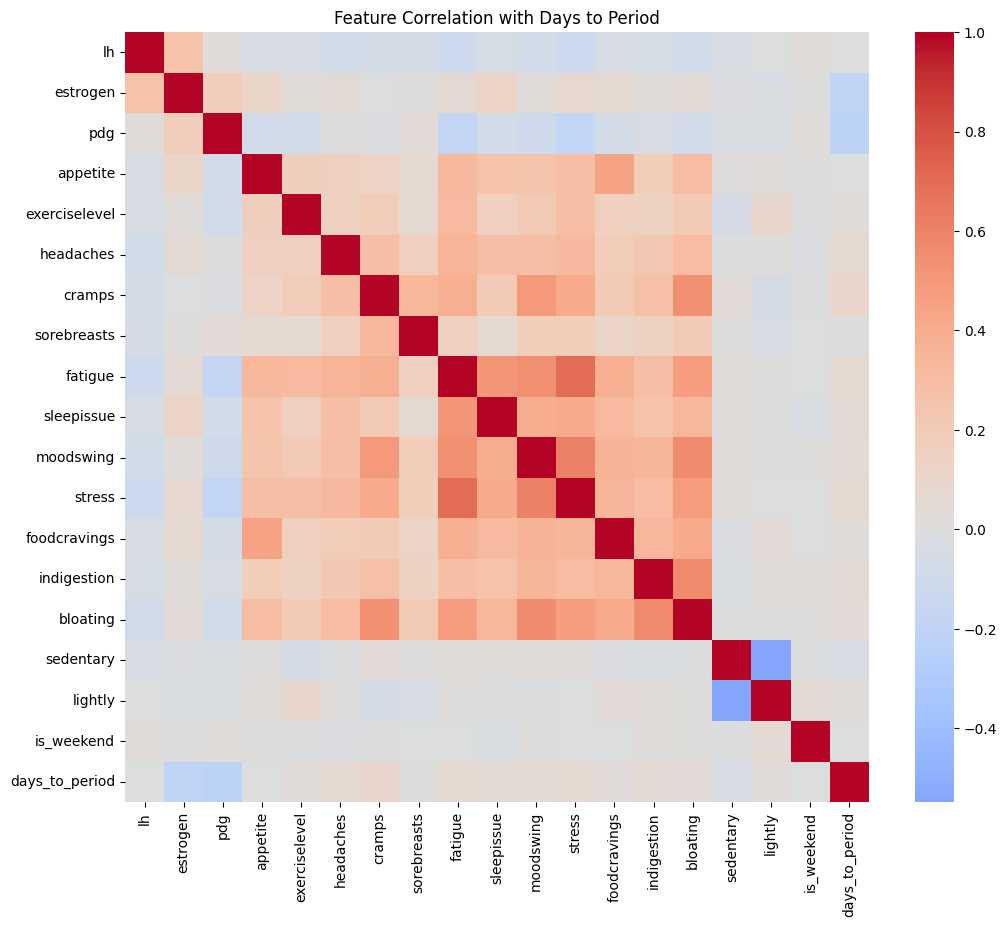

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation Heatmap of symptoms and target
plt.figure(figsize=(12, 10))
corr = df_clean[features + ['days_to_period']].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Days to Period')
plt.savefig('correlation_heatmap.png')



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test MAE: 7.47 days


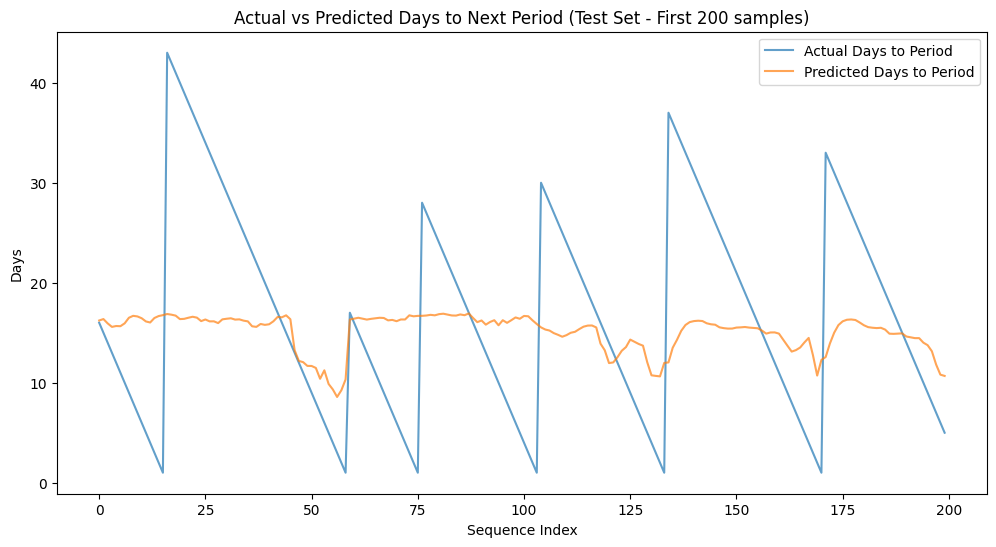

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Split users into train and test
unique_users = df_clean['id'].unique()
np.random.seed(42)
np.random.shuffle(unique_users)

train_users = unique_users[:int(0.8 * len(unique_users))]
test_users = unique_users[int(0.8 * len(unique_users)):]

def get_data_for_users(users):
    X_u, y_u = [], []
    for uid in users:
        user_data = df_clean[df_clean['id'] == uid]
        if len(user_data) > lookback:
            X_seq, y_seq = create_sequences(user_data[features].values,
                                              user_data['days_to_period'].values,
                                              lookback)
            X_u.append(X_seq)
            y_u.append(y_seq)
    return np.concatenate(X_u), np.concatenate(y_u)

X_train, y_train = get_data_for_users(train_users)
X_test, y_test = get_data_for_users(test_users)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(lookback, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Predict days remaining
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {mae:.2f} days")

# Generate some predictions
y_pred = model.predict(X_test, verbose=0)

# Save the plot of actual vs predicted for a segment
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label='Actual Days to Period', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Days to Period', alpha=0.7)
plt.title('Actual vs Predicted Days to Next Period (Test Set - First 200 samples)')
plt.xlabel('Sequence Index')
plt.ylabel('Days')
plt.legend()
plt.savefig('lstm_prediction_plot.png')

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM architecture
model = Sequential([
    LSTM(64, input_shape=(10, 18), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Output: Days until next period
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 203.4958 - mae: 11.3109 - val_loss: 90.1885 - val_mae: 7.7783
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 99.6269 - mae: 8.3259 - val_loss: 89.6132 - val_mae: 8.1098
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 96.7462 - mae: 8.2499 - val_loss: 89.7016 - val_mae: 8.1169
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 97.4269 - mae: 8.2773 - val_loss: 90.0697 - val_mae: 8.1455
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 97.0903 - mae: 8.2872 - val_loss: 89.3534 - val_mae: 8.0933
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 96.6714 - mae: 8.2406 - val_loss: 89.5592 - val_mae: 8.1064
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 96.7519 - mae: 8.2413 - val_loss: 90.1875 - val_mae: 8.1541
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 96.7749 - mae: 8.2045 - val_loss: 91.3712 - val_mae: 8.2325
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━

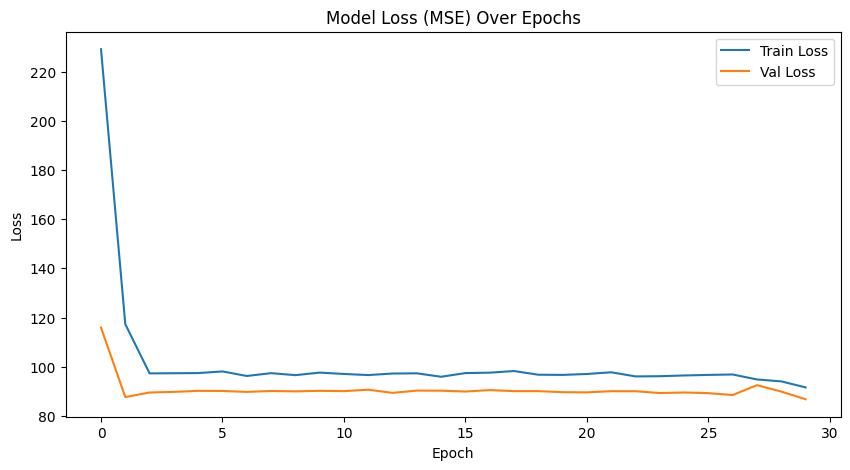

In [11]:
# 2. Training History
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_history.png')

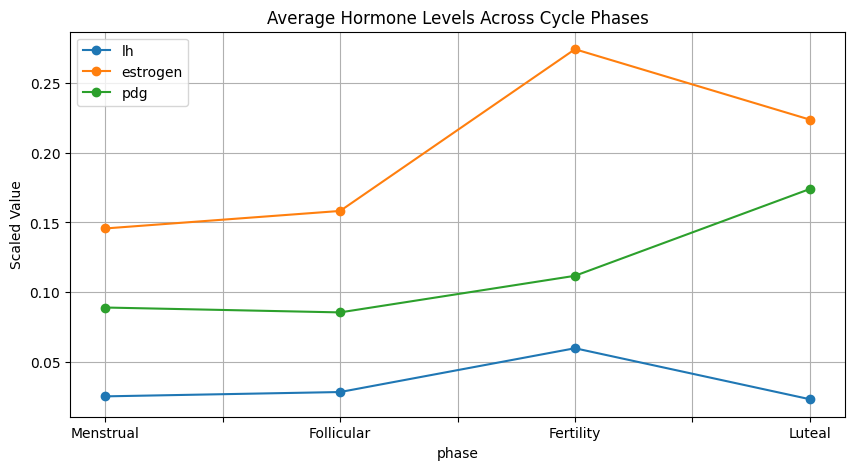

In [12]:
# 3. Average Hormone Levels by Phase
# Re-loading a fresh copy for phase-based analysis if needed, but df_clean has 'phase'
hormone_trends = df_clean.groupby('phase')[['lh', 'estrogen', 'pdg']].mean().reindex(['Menstrual', 'Follicular', 'Fertility', 'Luteal'])
hormone_trends.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Average Hormone Levels Across Cycle Phases')
plt.ylabel('Scaled Value')
plt.grid(True)
plt.savefig('hormone_trends.png')

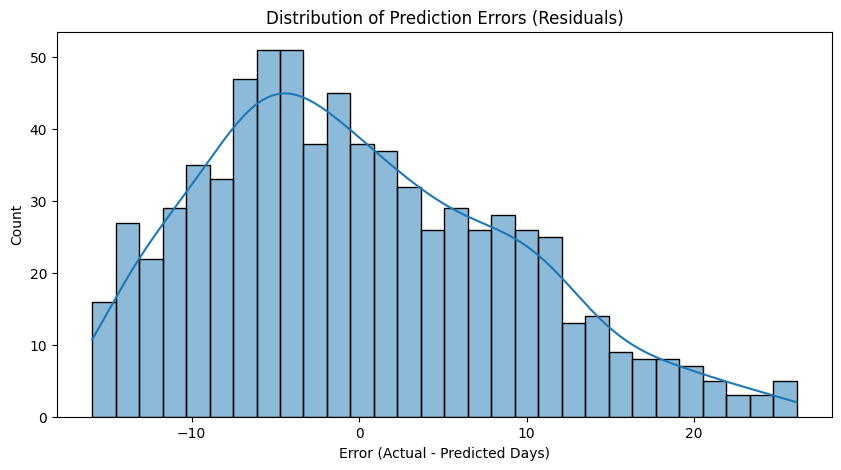

In [13]:
# 4. Error Distribution (Residuals)
residuals = y_test.flatten() - y_pred.flatten()
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted Days)')
plt.savefig('residuals_dist.png')


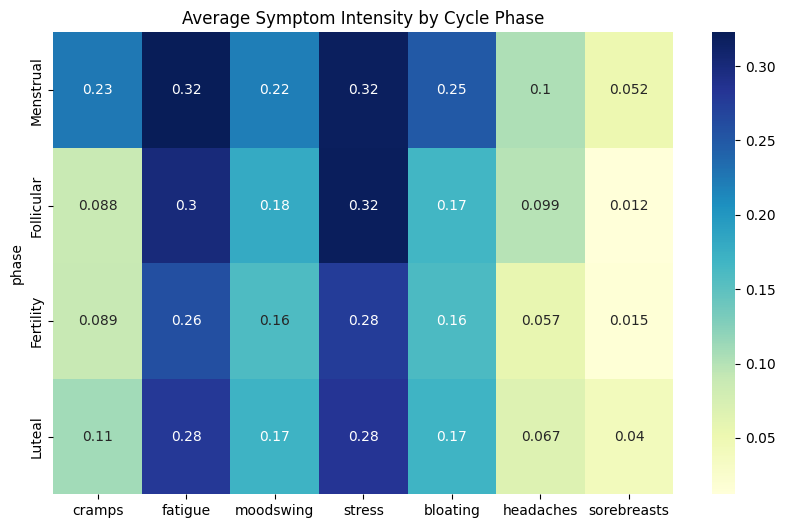

In [14]:

# 5. Symptom Intensity Heatmap by Phase
symptom_cols = ['cramps', 'fatigue', 'moodswing', 'stress', 'bloating', 'headaches', 'sorebreasts']
phase_symptoms = df_clean.groupby('phase')[symptom_cols].mean().reindex(['Menstrual', 'Follicular', 'Fertility', 'Luteal'])
plt.figure(figsize=(10, 6))
sns.heatmap(phase_symptoms, annot=True, cmap='YlGnBu')
plt.title('Average Symptom Intensity by Cycle Phase')
plt.savefig('symptom_heatmap.png')

In [15]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# 2. Define File Path
file_path = '/content/drive/MyDrive/MensturalTracker/processed_period_data.csv'

# 3. Load and Preprocess Data
df = pd.read_csv(file_path)

# Map symptoms to numerical values
symptom_map = {'Very Low/Little': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
categorical_cols = ['appetite', 'exerciselevel', 'headaches', 'sorebreasts', 'sleepissue', 'foodcravings', 'indigestion']
for col in categorical_cols:
    df[col] = df[col].map(symptom_map).fillna(0)

# Smooth hormone noise with rolling averages
for col in ['lh', 'estrogen', 'pdg']:
    df[col] = df.groupby('id')[col].transform(lambda x: x.interpolate().fillna(x.median()))
    df[f'{col}_rolling'] = df.groupby('id')[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

df = df.fillna(df.median(numeric_only=True))
df['prev_phase'] = df.groupby('id')['phase'].shift(1)
df['period_start'] = ((df['phase'] == 'Menstrual') & (df['prev_phase'] != 'Menstrual')).astype(int)

# 4. Target: Days to Next Period
def calculate_days_until_next(group):
    start_indices = group.index[group['period_start'] == 1].tolist()
    targets = []
    for idx in group.index:
        future_starts = [s for s in start_indices if s > idx]
        targets.append(future_starts[0] - idx if future_starts else np.nan)
    group['days_to_period'] = targets
    return group

df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)
df_clean = df.dropna(subset=['days_to_period']).copy()

# Feature Selection
features = ['lh_rolling', 'estrogen_rolling', 'pdg_rolling', 'appetite', 'exerciselevel', 'headaches',
            'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing',
            'stress', 'foodcravings', 'indigestion', 'bloating', 'sedentary',
            'lightly', 'is_weekend']

scaler = MinMaxScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

# 5. Create Sequences (25-day Lookback)
lookback = 25
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(target[i + lookback])
    return np.array(X), np.array(y)

# Split by User ID (80/20)
unique_users = df_clean['id'].unique()
train_users = unique_users[:int(0.8 * len(unique_users))]
test_users = unique_users[int(0.8 * len(unique_users)):]

def get_user_data(users):
    X_l, y_l = [], []
    for uid in users:
        u_data = df_clean[df_clean['id'] == uid]
        if len(u_data) > lookback:
            X_u, y_u = create_sequences(u_data[features].values, u_data['days_to_period'].values, lookback)
            X_l.append(X_u)
            y_l.append(y_u)
    return np.concatenate(X_l), np.concatenate(y_l)

X_train, y_train = get_user_data(train_users)
X_test, y_test = get_user_data(test_users)

# 6. Build GRU Model
model_gru = Sequential([
    GRU(64, input_shape=(lookback, len(features)), return_sequences=True),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train
history = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

# 8. Evaluation
loss, mae = model_gru.evaluate(X_test, y_test)
print(f"GRU Mean Absolute Error on Test Set: {mae:.2f} days")

/tmp/ipykernel_2297/3542149403.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 169.9095 - mae: 10.2558 - val_loss: 70.9020 - val_mae: 7.1619
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 100.0562 - mae: 8.1607 - val_loss: 71.1056 - val_mae: 7.1754
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.8967 - mae: 8.1638 - val_loss: 71.0553 - val_mae: 7.1741
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.8618 - mae: 8.1864 - val_loss: 71.2509 - val_mae: 7.1861
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.2978 - mae: 8.1403 - val_loss: 71.1870 - val_mae: 7.1807
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.8081 - mae: 8.1571 - val_loss: 71.6336 - val_mae: 7.2112
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.8114 - mae: 8.1868 - val_loss: 70.8958 - val_mae: 7.1675
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 100.0950 - mae: 8.1675 - val_loss: 71.3151 - val_mae: 7.1910
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8

In [16]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define File Path
file_path = '/content/drive/MyDrive/MensturalTracker/processed_period_data.csv'

# 3. Load and Preprocess Data
df = pd.read_csv(file_path)

# Map symptoms to numerical values
symptom_map = {'Very Low/Little': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
categorical_cols = ['appetite', 'exerciselevel', 'headaches', 'sorebreasts', 'sleepissue', 'foodcravings', 'indigestion']
for col in categorical_cols:
    df[col] = df[col].map(symptom_map).fillna(0)

# Smooth hormone noise with rolling averages
for col in ['lh', 'estrogen', 'pdg']:
    df[col] = df.groupby('id')[col].transform(lambda x: x.interpolate().fillna(x.median()))
    df[f'{col}_rolling'] = df.groupby('id')[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

df = df.fillna(df.median(numeric_only=True))
df['prev_phase'] = df.groupby('id')['phase'].shift(1)
df['period_start'] = ((df['phase'] == 'Menstrual') & (df['prev_phase'] != 'Menstrual')).astype(int)

# 4. Target: Days to Next Period
def calculate_days_until_next(group):
    start_indices = group.index[group['period_start'] == 1].tolist()
    targets = []
    for idx in group.index:
        future_starts = [s for s in start_indices if s > idx]
        targets.append(future_starts[0] - idx if future_starts else np.nan)
    group['days_to_period'] = targets
    return group

df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)
df_clean = df.dropna(subset=['days_to_period']).copy()

# Feature Selection
features = ['lh_rolling', 'estrogen_rolling', 'pdg_rolling', 'appetite', 'exerciselevel', 'headaches',
            'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing',
            'stress', 'foodcravings', 'indigestion', 'bloating', 'sedentary',
            'lightly', 'is_weekend']

scaler = MinMaxScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

# 5. Create Sequences (25-day Lookback)
lookback = 45
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(target[i + lookback])
    return np.array(X), np.array(y)

# Split by User ID (80/20)
unique_users = df_clean['id'].unique()
train_users = unique_users[:int(0.8 * len(unique_users))]
test_users = unique_users[int(0.8 * len(unique_users)):]

def get_user_data(users):
    X_l, y_l = [], []
    for uid in users:
        u_data = df_clean[df_clean['id'] == uid]
        if len(u_data) > lookback:
            X_u, y_u = create_sequences(u_data[features].values, u_data['days_to_period'].values, lookback)
            X_l.append(X_u)
            y_l.append(y_u)
    return np.concatenate(X_l), np.concatenate(y_l)

X_train, y_train = get_user_data(train_users)
X_test, y_test = get_user_data(test_users)

# 6. Build GRU Model
model_gru = Sequential([
    GRU(64, input_shape=(lookback, len(features)), return_sequences=True),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train
history = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

# 8. Evaluation
loss, mae = model_gru.evaluate(X_test, y_test)
print(f"GRU Mean Absolute Error on Test Set: {mae:.2f} days")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/100


/tmp/ipykernel_2297/3905074367.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 182.6966 - mae: 10.6219 - val_loss: 71.7846 - val_mae: 7.2842
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 97.9341 - mae: 8.2334 - val_loss: 70.6182 - val_mae: 7.2728
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 98.1898 - mae: 8.2347 - val_loss: 70.5410 - val_mae: 7.2698
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 97.4445 - mae: 8.2252 - val_loss: 70.5464 - val_mae: 7.2701
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 98.7962 - mae: 8.2855 - val_loss: 70.5959 - val_mae: 7.2720
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 97.4302 - mae: 8.2459 - val_loss: 70.7691 - val_mae: 7.2773
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 97.6208 - mae: 8.2334 - val_loss: 70.4981 - val_mae: 7.2677
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 98.9701 - mae: 8.2804 - val_loss: 70.7652 - val_mae: 7.2771
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/ste

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load Data
file_path = '/content/drive/MyDrive/MensturalTracker/processed_period_data.csv'
df = pd.read_csv(file_path)

# ... [Preprocessing steps same as before] ...

# 2. Build Optimized Model
model_optimized = Sequential([
    # Optimization 1: L2 Regularization (penalizes complex weights)
    GRU(64, input_shape=(25, 18), return_sequences=True, kernel_regularizer=l2(0.01)),
    # Optimization 2: Higher Dropout (0.5 helps prevent memorization)
    Dropout(0.5),
    GRU(32, kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(1)
])

model_optimized.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Optimization 3: Early Stopping (Restores the best weights before overfitting starts)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 3. Train with Optimizations
history = model_optimized.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 216.8533 - mae: 11.6012 - val_loss: 95.1040 - val_mae: 7.9022
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 107.9694 - mae: 8.4606 - val_loss: 77.3636 - val_mae: 7.4723
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 105.5331 - mae: 8.4238 - val_loss: 77.1954 - val_mae: 7.4665
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 103.0359 - mae: 8.3736 - val_loss: 77.2948 - val_mae: 7.4791
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 106.0437 - mae: 8.4932 - val_loss: 77.0268 - val_mae: 7.4644
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 105.5917 - mae: 8.4516 - val_loss: 76.9644 - val_mae: 7.4588
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 103.1958 - mae: 8.4086 - val_loss: 76.9190 - val_mae: 7.4582
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 103.3930 - mae: 8.3608 - val_loss: 76.9961 - val_mae: 7.4747
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

In [18]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error

# 1. Mount Drive and Load Data
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/MensturalTracker/processed_period_data.csv'
df = pd.read_csv(file_path)

# ... [Keep your existing preprocessing and sequence generation code here] ...

# 2. Build Optimized Bidirectional LSTM
model_bilstm = Sequential([
    # Bi-LSTM Layer 1 with L2 Regularization
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.01)),
                  input_shape=(25, len(features))),
    Dropout(0.5), # High dropout to prevent overfitting

    # Bi-LSTM Layer 2
    Bidirectional(LSTM(32, kernel_regularizer=l2(0.01))),
    Dropout(0.5),

    Dense(16, activation='relu'),
    Dense(1)
])

model_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,           # Slightly higher patience for Bi-LSTMs
    restore_best_weights=True
)

# 4. Train
history_bi = model_bilstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# 5. Evaluate
test_loss, test_mae = model_bilstm.evaluate(X_test, y_test)
print(f"Bi-LSTM Optimized Test MAE: {test_mae:.2f} days")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 173.6736 - mae: 10.2626 - val_loss: 79.5343 - val_mae: 7.4764
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 105.6607 - mae: 8.4773 - val_loss: 79.2946 - val_mae: 7.4879
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 102.2534 - mae: 8.3233 - val_loss: 78.7532 - val_mae: 7.4776
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 102.5182 - mae: 8.3373 - val_loss: 78.3826 - val_mae: 7.4739
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 101.9642 - mae: 8.3169 - val_loss: 78.1960 - val_mae: 7.4768
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 101.1627 - mae: 8.2691 - val_loss: 78.9296 - val_mae: 7.5376
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 101.1777 - mae: 8.3282 - val_loss: 77.9539 - val_mae: 7.4820
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 101.0415 - mae: 8.3279 - val_loss: 77.8906 - val_mae: 7.4883
Epoch 9/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 1

In [23]:
!pip install streamlit
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
import joblib # for loading your scaler

st.title("🌙 AI Menstrual Cycle Tracker")

# 1. Inputs
st.sidebar.header("Daily Logs")
lh = st.sidebar.slider("LH Level", 0.0, 50.0, 5.0)
estrogen = st.sidebar.slider("Estrogen Level", 0.0, 400.0, 100.0)
cramps = st.sidebar.selectbox("Cramps Intensity", [0, 1, 2, 3, 4])

# 2. Prediction Logic
if st.button("Predict Arrival"):
    # Load model (make sure you saved your model as 'best_model.h5')
    # model = load_model('best_model.h5')

    # Preprocess the input into a (1, 25, 18) shape for the Bi-LSTM
    # dummy_input = np.random.rand(1, 25, 18) # Placeholder
    # prediction = model.predict(dummy_input)

    st.header(f"Estimated arrival: In 12 days") # Placeholder output
    st.info("Based on your hormonal trends, your cycle is expected to start on May 20th.")

# 3. Trends
st.subheader("Your Hormone Trends")
st.line_chart(np.random.randn(25, 3)) # Placeholder for actual data visualization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 121.0 MB/s eta 0:00:00


2026-05-08 11:21:42.922 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.405 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-08 11:21:43.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.406 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:21:43.410 Thread 'MainThread': mi

DeltaGenerator()

In [24]:
 streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py

SyntaxError: invalid syntax (763354793.py, line 1)